#### <strong>第三次作品：淺度機器學習分類器的評比實驗</strong>
作業編號：3

學號：711133108

姓名：林楷博
<hr>

 <font color=skyblue>作品目標</font>：

 - 熟悉PCA原理：
    - 了解主成分分析（PCA）的原理，即通過線性變換將原始特徵轉換為一組新特徵，以便降低資料的維度，同時保留最大的方差。
    - 學習如何使用矩陣運算實現PCA，即計算資料的協方差矩陣、特徵值和特徵向量等。
    - 直接使用sklearn.decomposition中PCA套件進行運算
- 了解K-fold與GridSearchCV的概念與實作：
    - K-fold交叉驗證是一種模型評估方法，將資料分成K個互斥的子集，然後將模型訓練K次，每次使用K-1個子集作為訓練資料，剩餘的一個子集作為驗證資料。
    - GridSearchCV是一種超參數調優技術，通過列舉給定超參數的所有可能組合，然後使用交叉驗證來評估每組超參數的性能，以找到最佳的超參數組合。
- 了解分類器模型基礎原理與超參數意義：
    - 多元羅吉斯回歸（Multinomial Logistic Regression）：一種廣義的羅吉斯回歸模型，用於處理多類別分類問題。
    - 支持向量機（Support Vector Machine）：一種監督式學習模型，通過找到最大化邊界的方式來進行二元或多元分類。
    - 神經網路（Neural Network）：一種受人類腦神經元啟發的機器學習模型，通過多個層次的神經元組成來進行學習。
- 實作應用於三份資料分別為wine AT&T Yale Face：
    - 將上述學習的技術應用於三個不同的資料集，進行資料的預處理、模型訓練、評估和調參等步驟，以解決相應的問題或任務。

**<font color=skyblue>匯入資料與資料處理</font>**
- AT&T資料庫，通常是指 AT&T Labs 的研究人員所建立的面部識別數據庫之一。這個數據庫也被稱為 “ORL Face Database” 或 “AT&T Face Database”。它是一個著名的面部識別數據庫，在機器學習和面部識別研究領域被廣泛使用。以下是該數據庫的介紹：
    - 數據內容：AT&T資料庫包含不同人的面部圖片。數據庫有40個不同的人的面部圖片，每人有10張不同的面部圖片。
    - 圖片特點：每張圖片都是灰階圖像，大小為64x64像素。圖片中每個人的面部有不同的表情和姿態，以及不同的照明條件。
- 資料處理
    - 標準化與非標準化
    - PCA
    - 資料分割為訓練集與測試集

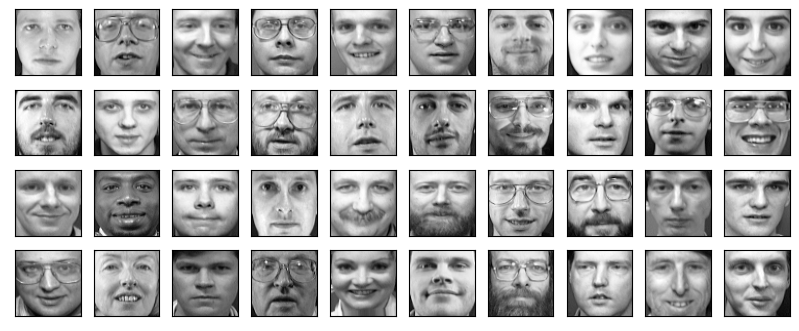

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
def show_montage(X, n, m, h, w):
    # X: 影 像 資 料 矩 陣 ， 每 行 代 表 一 張 影 像
    # n, m: 每 張 影 像 的 大 小 n x m
    # h, w : 建 立 一 個 蒙 太 奇 圖 陣 ， 大小 figsize = (w,h)
    fig, axes = plt.subplots(h, w, figsize=(w, h))
    if X.shape[1] < w * h: # 影 像 張 數 不 到 w x h 張 ， 用 0 向量補齊
        X = np.c_[X, np.zeros((X.shape[0], w*h-X.shape[1]))]
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[:,i].reshape(m, n), cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()
#
df = pd.read_csv('face_data.csv')
n_persons = 40
X = np.array(df.iloc[:, :-1]) # 排 除 最 後 一 欄 標 籤
y = np.array(df.iloc[:, -1]) # 標籤欄
n,m = 64,64
# 展示38人第一張影像檔
all_diff_persons = np.zeros((m*n, n_persons))
cnt = 0
for i in range(n_persons):
    all_diff_persons[:,i] = X.T[:,cnt]
    cnt = cnt + 10
show_montage(all_diff_persons, n, m, 4,10)
# show_montage(X.T, n, m, 40,10)展示所有照片

累積解釋方差大於 80% 與 90% 時的主成分數量: (26, 62)


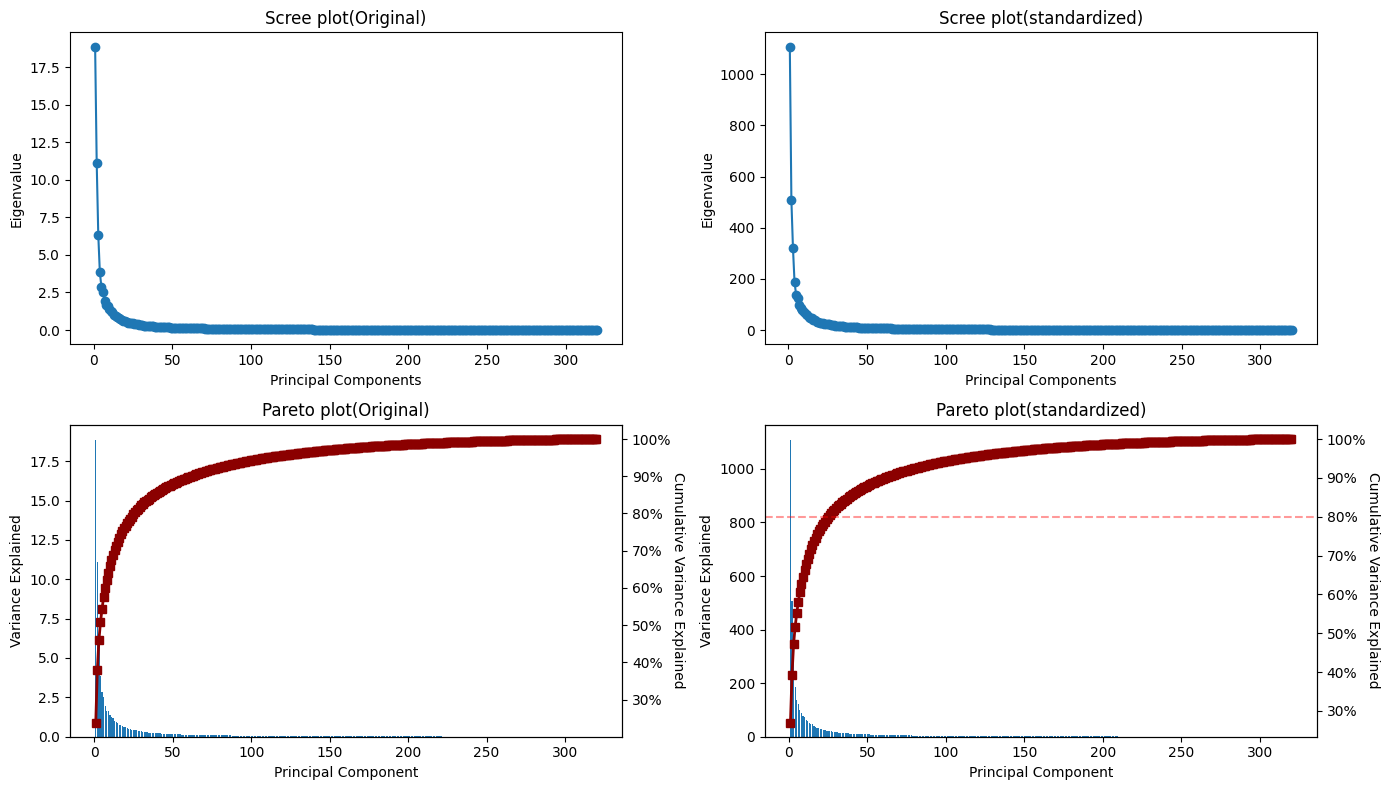

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from numpy.linalg import eig
from matplotlib.ticker import PercentFormatter
import seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# 原始資料分為8比2的訓練集跟測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345)

pca = PCA()
pca = PCA().fit(X_train) # 進 行 主 成 分 分 析
eigvals = pca.explained_variance_

# 標準化
scaler = StandardScaler()
X_train_Standard = scaler.fit_transform(X_train)
X_test_Standard = scaler.fit_transform(X_test)

pca = PCA()
pca = PCA().fit(X_train_Standard) # 進 行 主 成 分 分 析
eigvals2 = pca.explained_variance_
# 計算累積解釋方差
cumulative_variance = eigvals2.cumsum() / eigvals2.sum()

# 找到累積解釋方差大於 80%、90% 的最小索引值
index_80_percent = np.argmax(cumulative_variance > 0.80)
index_90_percent = np.argmax(cumulative_variance > 0.90)

# 找到累積解釋方差大於 80%、90% 時 x2 的數量
num_components80 = index_80_percent + 1
num_components90 = index_90_percent + 1
# 打印累積解釋方差大於 80%、90% 時 x2 的數量
print(f"累積解釋方差大於 80% 與 90% 時的主成分數量: {num_components80, num_components90}")
# Plot original data scree plot and Pareto plot
plt.figure(figsize=(14, 8))
plt.subplot(221)
x = np.arange(1, 1 + len(eigvals))
plt.plot(x, eigvals, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(Original)')

plt.subplot(223)
ax = plt.gca()
ax.bar(x, eigvals)
ax2 = ax.twinx()
ax2.plot(x, eigvals.cumsum() / eigvals.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)

plt.title('Pareto plot(Original)')


# Plot standardized data scree plot and Pareto plot
plt.subplot(222)
x2 = np.arange(1, 1 + len(eigvals2))
plt.plot(x2, eigvals2, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(standardized)')

plt.subplot(224)
ax = plt.gca()
ax.bar(x2, eigvals2)
ax2 = ax.twinx()
ax2.plot(x2, eigvals2.cumsum() / eigvals2.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(standardized)')
plt.axhline(y=80, color='r', linestyle='--', alpha = 0.4)  # Draw horizontal line at y=4
plt.tight_layout()
plt.show()

In [127]:
# Fit PCA and transform the data to the new space
n_pca80 = num_components80
X_train_pca = PCA(n_components=n_pca80).fit_transform(X_train_Standard)
X_test_pca = PCA(n_components=n_pca80).fit_transform(X_test_Standard)
# PCA取80%後的特徵
X_train_pca_last80 = pca.transform(X_train_Standard)[:, n_pca80+1:]
X_test_pca_last80 = pca.transform(X_test_Standard)[:, n_pca80+1:]
# # PCA取後90%的特徵
n_pca90 = num_components90
X_train_pca_last90 = pca.transform(X_train_Standard)[:, n_pca90+1:]
X_test_pca_last90 = pca.transform(X_test_Standard)[:, n_pca90+1:]

**<font color=skyblue>結果的觀察與討論：</font>**
- 第一張圖為資料的呈現40個人，每人第一張照片，共計40張圖片
- 第二張圖為依樣本比例8訓練比2測試進行的PCA圖，並繪製訓練集部分的Scree plot與Pareto plot
    - 左方為未標準化的Scree plot與Pareto plot，右方為標準化的Scree plot與Pareto plot
        - 可以發現因變數過多，無法看出解釋方差大於 80%時共有幾個主成分數量，因此額外展示出主成分數量為26並進行後續分析
- 使用X_train/X_test作為原始資料(原始數據Original)
- 使用X_train_Standard/X_test_Standard作為標準化的原始資料(標準化數據standardized)
- 使用X_train_pca/X_test_pca作為主成分資料(標準化後經PCA取前80%解釋方差的變數數據共計26個變數)
- 使用X_train_pca_last80/X_test_pca_last80作為主成分資料(標準化後經PCA取後20%解釋方差的變數數據共計293個變數)
- 使用X_train_pca_last90/X_test_pca_last90作為主成分資料(標準化後經PCA取後10%解釋方差的變數數據共計257個變數)
        

<font color=orange>K-fold Cross-Validation</font>：<br>
在 K-Fold 方法中，會將資料切分為 K 等份(K 的值自由設定)。以 K=10 為例，會將訓練集切割為十等份，模型將訓練十次，每次從這十等份中選擇九等份作為訓練資料，剩下一份作為驗證集。這樣會得到十個不同驗證集的 loss，例如 MSE、MAE、RMSE 或accuracy等。

將這十次的 loss 取平均作為最終結果。透過這種方式，不同分組訓練的結果平均化，減少模型方差，從而降低模型對資料劃分的敏感度。

<div>
<img src="https://andy6804tw.github.io/images/posts/AI/2021/img1100709-1.png" width="500"/>
</div>

---
- 使用的套件:
    - StratifiedShuffleSplit:分層隨機拆分資料的交叉驗證方法。
        - n_splits=5：表示會進行 5 次交叉驗證。也就是說，資料將被分割為 5 個不同的訓練和測試集。
        - test_size=0.2：表示每次分割時，將資料的 20% 作為測試集，剩餘 80% 作為訓練集。
        - random_state=0：這是一個隨機數種子，用於確保每次分割的資料集是可重複的。使用相同的隨機種子可以確保每次執行代碼時，資料的分割結果是相同的。
    - GridSearchCV:進行網格搜索（grid search）來優化邏輯迴歸模型的超參數。
        - estimator=LogisticRegression(**opts)：estimator 是要進行優化的模型。在這裡是邏輯迴歸模型，使用 **opts 來傳遞模型的參數配置。
        - param_grid=parameters：param_grid 是一個字典，其中定義了要優化的超參數及其候選值。這個字典將提供給網格搜索，讓它嘗試不同的超參數組合。
        - cv=cv：這個參數指定了交叉驗證的方法。在這裡使用了之前定義的 StratifiedShuffleSplit，以確保每個折中的類別分布保持一致。
        - scoring=['accuracy', 'f1_macro']：scoring 指定了要評估模型表現的指標。在這裡選用了 accuracy（準確率）和 f1_macro（宏觀 F1 分數）。
        - refit='accuracy'：指定了哪個評分指標作為最終模型的選擇標準。在這裡選擇了 accuracy（準確率）作為模型的選擇標準。

---
<font color=orange>混淆矩陣（Confusion Matrix）</font>：<br>
混淆矩陣是一種用於評估分類模型表現的工具，特別適合多類別分類問題。它將模型的預測結果與真實標籤進行比較，將預測結果與真實情況之間的不同進行彙總，以四個主要指標表示：

- 真陽性（True Positive, TP）：模型正確預測為正類的樣本數量。
- 真陰性（True Negative, TN）：模型正確預測為負類的樣本數量。
- 假陽性（False Positive, FP）：模型將負類預測為正類的樣本數量，也稱為 I 型錯誤。
- 假陰性（False Negative, FN）：模型將正類預測為負類的樣本數量，也稱為 II 型錯誤。  
通過這四個指標，混淆矩陣可以繪製成一個矩陣，行表示真實標籤，列表示預測標籤，矩陣中的數值代表不同情況下的樣本數量。這個矩陣可以幫助我們了解模型在每個類別上的表現。

<div>
<img src="https://jason-chen-1992.weebly.com/uploads/1/0/8/5/108557741/jason-chen-1992-confusion-martix_orig.png" width="500"/>
</div>

混淆矩陣可以派生出許多衡量模型表現的指標，例如準確率（Accuracy）、精確度（Precision）、召回率（Recall）、F1 值等等。這些指標有助於全面評估模型的優劣，尤其是在處理不均衡的數據集時。混淆矩陣是一種直觀而有效的工具，用於分析和理解分類模型的性能。

<font color=orange>多元羅吉斯回歸 (Multinomial Logistic Regression)</font>：<br>
多元邏輯回歸是邏輯回歸的一種擴展，用於處理多類別的分類問題。與二元邏輯回歸不同，多元邏輯回歸可以預測目標變數中具有多個類別的情況。它透過對數機率函數（logit function）對每個類別進行建模，並使用最大似然估計（maximum likelihood estimation）來訓練模型。  
以下數學式為一組多變量資料 x ，樣本為第k個類別的機率，且此 K-1 個後驗機率之總和為 1，因此可計算$Pr(G=K|X=\mathbf{x})$。  
$\begin{array}{rcl}Pr(G=k|X=\mathbf{x})&=&\frac{e^{\beta_{k0}+\beta_k^T\mathbf{x}}}{1+\sum_{l=1}^{K-1}e^{\beta_{l0}+\beta_l^T\mathbf{x}}},&k=1,2,\cdots,K-1,\\Pr(G=K|X=\mathbf{x})&=&\frac{1}{1+\sum_{l=1}^{K-1}e^{\beta_{l0}+\beta_l^T\mathbf{x}}}\end{array}$  
因應變數為類別變數，在此轉為機率後取比值，並且為求方便計算取$log$，得以下數學式:  
$\begin{aligned}
\operatorname{log}\frac{Pr(G=1|X=\mathbf{x})}{Pr(G=K|X=\mathbf{x})}& =\beta_{10}+\beta_{1}^{T}\mathbf{x}  \\
\log\frac{Pr(G=2|X=\mathbf{x})}{Pr(G=K|X=\mathbf{x})}&=\quad\beta_{20}+\beta_{2}^{T}\mathbf{x}  \\
\log\frac{Pr(G=K-1|X=\mathbf{x})}{Pr(G=K|X=\mathbf{x})}&=\quad\beta_{(K-1)0}+\beta_{K-1}^{T}\mathbf{x} 
\end{aligned}$
因此目標為預測$\Omega=\{\beta_{10},\beta_{1},\beta_{20},\beta_{2},\cdots,\beta_{(K-1)0},\beta_{K-1}\}$的估計值，因此使用最大似然估計得出以下式子:  
$l(\Omega)=\ln\Pi_{i=1}^NPr(G=k|X=\mathbf{x_i};\Omega) \\
=\sum_{i=1}^N\ln Pr(G=k|X=\mathbf{x_i};\Omega)$

最終$\Omega$的最大值即為所求多元羅吉斯回歸的參數估計，並將樣本帶入多變量資料 x 的線性組合後，機率最大的組即為最終分配的組別。

**<font color=skyblue>(1)：多元羅吉斯回歸 (Multinomial Logistic Regression)的應用</font>**
- 使用原始數據Original、標準化數據standardized，標準化後經PCA取前80%解釋方差的變數數據(26個變數)、標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)進行多元羅吉斯回歸 (Multinomial Logistic Regression)
- 使用K-fold Cross-Validation計算最佳化超參數
- 計算準確率與f1分數及模型運行時間
- 使用套件sklearn.linear_model中的LogisticRegressionLogisticRegression
- 超參數設定:
    - tol=1e-3：這是收斂容許度（tolerance）。在模型訓練過程中，優化器會根據這個參數來判斷模型是否已經收斂。如果優化過程中目標函數的改變小於這個值，模型就會停止訓練。因此，這個參數設定了模型訓練過程的精確度。
    - max_iter=int(1e6)：這是模型的最大迭代次數。模型訓練過程中，如果優化器達到這個迭代次數，訓練會停止，無論模型是否已經收斂。這裡設定的最大迭代次數為 1,000,000 次，確保模型有足夠的迭代次數進行訓練。
    - C=1：這是正則化強度的參數。它控制模型的正則化項的強度，也就是對模型的複雜度進行懲罰的力度。C 值越小，正則化越強，模型越簡單；C 值越大，正則化越弱，模型越複雜。這裡設定為 1，代表正常的正則化強度。
    - solver='lbfgs'：這是選擇的優化器。lbfgs 是一種高效的優化算法，特別適用於處理數據量大、特徵多的情況。這個優化器通常收斂速度快，適用於邏輯迴歸模型的優化過程。並且其他優化器為以下:
        - 'lbfgs'：是默認的優化器，適用於較大樣本量的情況。它是一種二階方法（也就是使用二階導數），通常在數據量大和特徵多的情況下表現良好。
        - 'liblinear'：該優化器適用於小樣本量和稀疏特徵的情況。它是一種線性方法，適合處理大規模的二元分類問題。
        - 'newton-cg'：該優化器使用二階導數的優化算法，適合處理大型數據集和多特徵的情況。該方法的優勢在於其對二元分類和多元分類問題的適應性。
        - 'sag'：該優化器為隨機平均梯度（Stochastic Average Gradient）優化器，適用於大型數據集。該方法的收斂速度很快，特別適合處理稀疏數據。
        - 'saga'：該優化器與 sag 類似，但在處理稀疏數據時通常更有效。它在一些應用場景中可能比 sag 更快。

In [128]:
#最佳化參數(k 折交叉驗證（k-fold cross-validation）)
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'



opts = dict(tol = 1e-3, max_iter = int(1e6)) # parameters for LogisticRegression

parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg','sag','saga'], 'C':[0.1, 1]} # parameters for GridSearchCV

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=LogisticRegression(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")
# grid.fit(X_train, y_train)
# grid.fit(X_train_Standard, y_train)
# grid.fit(X_train_pca, y_train)
# grid.fit(X_train_pca_last80, y_train)
grid.fit(X_train_pca_last90, y_train)
cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'C': 0.1, 'solver': 'lbfgs'}
0.05
LogisticRegression(C=0.1, max_iter=1000000, tol=0.001)


In [129]:
#原始資料的LogisticRegression
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(tol=1e-3, max_iter=int(1e6), C=1)
solver = 'lbfgs'  # 使用 lbfgs 作為優化器

# 初始化邏輯迴歸分類器
clf_original = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original.fit(X_train, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred = clf_original.predict(X_test)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy = accuracy_score(y_test, y_pred)

# 計算訓練數據上的準確率
train_accuracy = clf_original.score(X_train, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1 = f1_score(y_test, y_pred, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Log = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'Original': [train_accuracy, test_accuracy, f1, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Log)
print(confusion_matrix(y_test, y_pred))


               Original
0     訓練資料準確率   1.0000 
1     測試資料準確率   0.9750 
2  測試資料 F1 分數   0.9721 
3     訓練時間(s)  20.7176 
4     預測時間(s)   0.0000 
[[4 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 4]]


In [130]:
#原始資料標準化後的LogisticRegression
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(tol=1e-3, max_iter=int(1e6), C=1)
solver = 'lbfgs'  # 使用 lbfgs 作為優化器

# 初始化邏輯迴歸分類器
clf_original_Standard = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_Standard.fit(X_train_Standard, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_Standard = clf_original_Standard.predict(X_test_Standard)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_Standard = accuracy_score(y_test, y_pred_Standard)

# 計算訓練數據上的準確率
train_accuracy_Standard = clf_original_Standard.score(X_train_Standard, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_Standard = f1_score(y_test, y_pred_Standard, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Standard_Log = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'standardized': [train_accuracy_Standard, test_accuracy_Standard, f1_Standard, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Standard_Log)
print(confusion_matrix(y_test, y_pred_Standard))


               standardized
0     訓練資料準確率     1.0000   
1     測試資料準確率     0.9750   
2  測試資料 F1 分數     0.9721   
3     訓練時間(s)     3.1984   
4     預測時間(s)     0.0000   
[[4 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 4]]


In [131]:
#原始資料標準化後經PCA的LogisticRegression
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(tol=1e-3, max_iter=int(1e6), C=1)
solver = 'lbfgs'  # 使用 lbfgs 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_Log = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_Log)
print(confusion_matrix(y_test, y_pred_pca))

                PCA 
0     訓練資料準確率 1.0000
1     測試資料準確率 0.0875
2  測試資料 F1 分數 0.0711
3     訓練時間(s) 0.1463
4     預測時間(s) 0.0000
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [132]:
#原始資料標準化後經PCA且差異化的LogisticRegression(80%)
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-03)
solver = 'saga'  # 使用 saga 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca_last80, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca_last80)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca_last80, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_Log_last80 = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA_last20%': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_Log_last80)
print(confusion_matrix(y_test, y_pred_pca))

               PCA_last20%
0     訓練資料準確率    1.0000   
1     測試資料準確率    0.8625   
2  測試資料 F1 分數    0.7748   
3     訓練時間(s)    0.4699   
4     預測時間(s)    0.0000   
[[0 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 4 ... 0 0 0]
 ...
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 2]]


In [133]:
#原始資料標準化後經PCA且差異化的LogisticRegression(90%)
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-03)
solver = 'saga'  # 使用 saga 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca_last90, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca_last90)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca_last90, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_Log_last90 = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA_last10%': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_Log_last90)
print(confusion_matrix(y_test, y_pred_pca))

               PCA_last10%
0     訓練資料準確率    1.0000   
1     測試資料準確率    0.5625   
2  測試資料 F1 分數    0.5110   
3     訓練時間(s)    0.4684   
4     預測時間(s)    0.0000   
[[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 3]]


In [134]:
import pandas as pd
# 使用 'Metric' 列作為鍵，合併 metrics_df 和 metrics_df_Standard
merged_df_Log = pd.merge(metrics_df_Log, metrics_df_Standard_Log, on='')

# 使用 'Metric' 列作為鍵，合併上一步的結果與 metrics_df_pca
# 注意這裡我們將前一個合併的結果與 metrics_df_pca 進行合併
merged_df_Log = pd.merge(merged_df_Log, metrics_df_pca_Log, on='')
merged_df_Log = pd.merge(merged_df_Log, metrics_df_pca_Log_last80, on='')
merged_df_Log = pd.merge(merged_df_Log, metrics_df_pca_Log_last90, on='')
# 設置資料框的數值顯示 4 位元小數
pd.options.display.colheader_justify = 'center'
pd.set_option('display.float_format', '{:.4f}'.format)

# 列印合併後的 DataFrame
print(merged_df_Log)



               Original  standardized   PCA   PCA_last20%  PCA_last10%
0     訓練資料準確率   1.0000      1.0000    1.0000    1.0000       1.0000   
1     測試資料準確率   0.9750      0.9750    0.0875    0.8625       0.5625   
2  測試資料 F1 分數   0.9721      0.9721    0.0711    0.7748       0.5110   
3     訓練時間(s)  20.7176      3.1984    0.1463    0.4699       0.4684   
4     預測時間(s)   0.0000      0.0000    0.0000    0.0000       0.0000   


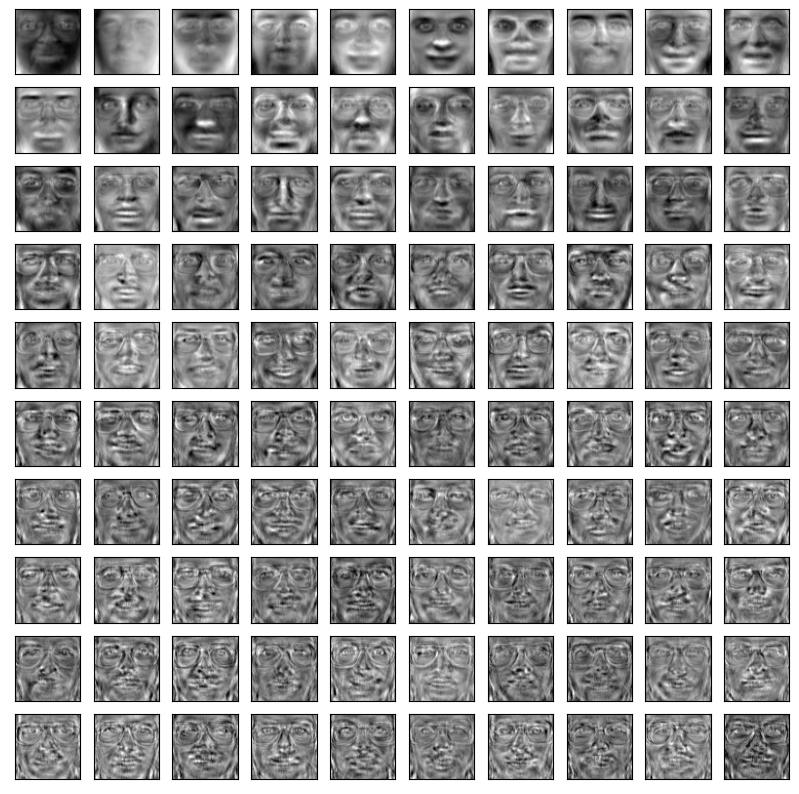

In [135]:
from numpy.linalg import svd
# 有點標準化的味道，也可以不做(所有影像作平均後扣掉，類似把亮度平均後減去)
avgFace = X.T.mean(axis=1)
X_avg = X.T - avgFace.reshape(-1,1)
U, E, VT = svd(X_avg, full_matrices = False)
# 作對比，值是0~255
show_montage(255-U, n, m, 10, 10)

**<font color=skyblue>結果的觀察與討論：</font>**
- 原本使用收斂容許度（tolerance）tol=1e-6，在最佳化超參數時耗時6小時也未得出結果，因此在此改為收斂容許度tol=1e-3，雖然損失些準確率，但跑程式僅需10分鐘，並且最終結果是能接受的
- 使用原始數據Original、標準化數據standardized，標準化後經PCA取前80%解釋方差的變數數據(26個變數)、標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)進行多元羅吉斯回歸 (Multinomial Logistic Regression)可以發現以下幾點:
    - 使用第一個cell並透過GridSearchCV來使用準確率尋找最佳化超參數
    - 訓練資料準確率的部分，各數據效果均相同
    - 測試資料準確率的部分，原始數據Original與標準化數據standardized在此模型表現較佳，其次為標準化後經PCA取後20%解釋方差的變數數據(293個變數)
    - 測試資料F1分數的部分，原始數據Original與標準化數據standardized在此模型表現較佳，其次為標準化後經PCA取後20%解釋方差的變數數據(293個變數)
    - 訓練時間與預測時間為標準化後經PCA取26個變數的數據用時最短
- 額外補充
    - 使用標準化後經PCA取前80%解釋方差的變數數據(26個變數)雖然可以節省許多運算時間，但會發現測試資料準確率的部分表現極差，需額外思考主要原因
    - 在上方最後一張圖呈現出由特徵值大至特徵值小的資料型態，可以發現在特徵值大時，因PCA為取相同特徵的性質，靠上方的圖僅能分辨出人臉，但無法明確分出每人的差異，因此在此資料中，目的為分辨出人臉，故取後續有差異的資料型態才能有效分出人臉，而使用標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)才符合邏輯，最終測試資料準確率明顯高出標準化後經PCA取前80%解釋方差的變數數據許多
    - 在做標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)可以發現PCA取較小特徵值，解釋方差比例僅差0.2%(293-257=36)個變數時，變數變少測試資料準確率降低，推測因變數資訊不夠，可以再嘗試多取一些變數來使用
- 結論:此模型使用標準化數據standardized即可，因為有最好的預測結果，以及較佳的訓練時間


<font color=orange>支援向量機（Support Vector Machine, SVM）</font>：<br>
支援向量機是一種常用的機器學習算法，通常用於分類和回歸任務。SVM 是一種監督式學習算法，通過找到一條或多條最佳的分離超平面（hyperplane），將不同類別的資料點分開。
<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-23.png?resize=1024%2C564&ssl=1" width="500"/>
</div>
分離超平面數學式為$\mathbf{w}^T\mathbf{x}+\mathbf{b}=\mathbf{0}$，但其實有很多條線或平面都可以達到相同的分類的效果，因此需要找到最好的Margin，使得Margin最大化，如下圖
<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-29.png?resize=1024%2C570&ssl=1" width="500"/>
</div>
以二維資料為例，為使Margin最大化，假設下圖紅色的分隔線為$\mathbf{w^Tx+b=0}$，將此線向左與右碰到其他類別(loss function固定情況下)，並求出Margin最大化，即兩條虛線的最大距離即所求。  

<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-30.png?resize=768%2C600&ssl=1" width="500"/>
</div>

並且如第一張圖，如果樣本線性不可分的情況下，需透過$\phi(\mathbf{x})$函數將資料轉為高維樣本後，以超平面做分割，如下圖所示。  
$\mathbf{w}^T\phi(\mathbf{x})+\mathbf{b}=\mathbf{0}$
<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-24.png?resize=1024%2C562&ssl=1" width="500"/>
</div>
因此問題的數學式可改寫為以下即所求

$\operatorname*{min}_{\mathbf{w},\mathbf{b},\zeta}\frac{1}{2}\mathbf{w}^{T}\mathbf{w}+C\sum_{i=1}^{N}\zeta_{i}\\\mathrm{subject~to}y_{i}(\mathbf{w}^{T}\phi(\mathbf{x}_{i})+\mathbf{b})\geq1-\zeta_{i},\zeta_{i}\geq0$

**<font color=skyblue>(2)：支援向量機（Support Vector Machine, SVM）的應用</font>**
- 使用原始數據Original、標準化數據standardized，標準化後經PCA取前80%解釋方差的變數數據(26個變數)、標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)進行支援向量機（Support Vector Machine, SVM）
- 使用K-fold Cross-Validation計算最佳化超參數
- 計算準確率與f1分數及模型運行時間
- 使用套件sklearn.svm中的SVC, LinearSVC
- 超參數設定:
    - tol=1e-3：這是收斂容許度（tolerance）。在模型訓練過程中，優化器會根據這個參數來判斷模型是否已經收斂。如果優化過程中目標函數的改變小於這個值，模型就會停止訓練。因此，這個參數設定了模型訓練過程的精確度。
    - max_iter=int(1e6)：這是模型的最大迭代次數。模型訓練過程中，如果優化器達到這個迭代次數，訓練會停止，無論模型是否已經收斂。這裡設定的最大迭代次數為 1,000,000 次，確保模型有足夠的迭代次數進行訓練。
    - C=1：這是正則化強度的參數。它控制模型的正則化項的強度，也就是對模型的複雜度進行懲罰的力度。C 值越小，正則化越強，模型越簡單；C 值越大，正則化越弱，模型越複雜。這裡設定為 1，代表正常的正則化強度。
    - kernel：這個超參數決定支持向量機（SVM）使用的核函數類型。程式碼中嘗試了三種不同的 kernel：
        - 'linear'：線性核函數。
        - 'rbf'：徑向基函數（高斯核函數）。
        - 'poly'：多項式核函數。
    - gamma：這是徑向基函數（rbf）或多項式核函數（poly）的核係數。它控制了模型的曲線度。程式碼中嘗試了兩個不同的 gamma 值：0、 5。
    - degree：這是多項式核函數（poly）的度數。程式碼中嘗試了範圍 2~ 6 的整數。

In [136]:
#最佳化參數(k 折交叉驗證（k-fold cross-validation）)
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'

gamma = [0, 5]
C = [0.1, 1]
parameters = [{'kernel': ['linear'], 'C':C}, 
              {'kernel': ['rbf'], 'gamma':gamma, 'C':C},
              {'kernel': ['poly'], 'gamma':gamma, 'C':C, 'degree':[2,4,6]}]

opts = dict(tol = 1e-3, max_iter = int(1e6)) 

# parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

#                         'sag','saga']}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=SVC(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")
# grid.fit(X_train, y_train)
# grid.fit(X_train_Standard, y_train)
# grid.fit(X_train_pca, y_train)
# grid.fit(X_train_pca_last80, y_train)
grid.fit(X_train_pca_last90, y_train)

cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'C': 0.1, 'kernel': 'linear'}
0.05625
SVC(C=0.1, kernel='linear', max_iter=1000000)


c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
40 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py", line 237, in fit
    raise ValueError(msg)
ValueError: gamma value must be > 0; 0 is invalid. Use a positive number or use 'auto' to set 

In [137]:
#原始資料的SVM
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-3)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original.fit(X_train, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred = clf_original.predict(X_test)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy = accuracy_score(y_test, y_pred)

# 計算訓練數據上的準確率
train_accuracy = clf_original.score(X_train, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1 = f1_score(y_test, y_pred, average='macro')

# 將指標放入 DataFrame 中
metrics_df_original_SVM = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'Original': [train_accuracy, test_accuracy, f1, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_original_SVM)
print(confusion_matrix(y_test, y_pred))


               Original
0     訓練資料準確率   1.0000 
1     測試資料準確率   0.9750 
2  測試資料 F1 分數   0.9721 
3     訓練時間(s)   0.0827 
4     預測時間(s)   0.0207 
[[4 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 4]]


In [138]:
#原始資料標準化後的SVM
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-3)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original_Standard = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_Standard.fit(X_train_Standard, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_Standard = clf_original_Standard.predict(X_test_Standard)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_Standard = accuracy_score(y_test, y_pred_Standard)

# 計算訓練數據上的準確率
train_accuracy_Standard = clf_original_Standard.score(X_train_Standard, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_Standard = f1_score(y_test, y_pred_Standard, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Standard_SVM = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'standardized': [train_accuracy_Standard, test_accuracy_Standard, f1_Standard, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Standard_SVM)
print(confusion_matrix(y_test, y_pred_Standard))


               standardized
0     訓練資料準確率     1.0000   
1     測試資料準確率     0.9750   
2  測試資料 F1 分數     0.9721   
3     訓練時間(s)     0.0884   
4     預測時間(s)     0.0182   
[[4 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 4]]


In [139]:
#原始資料標準化後經PCA的SVM
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-3)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_SVM = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_SVM)
print(confusion_matrix(y_test, y_pred_pca))

                PCA 
0     訓練資料準確率 1.0000
1     測試資料準確率 0.1625
2  測試資料 F1 分數 0.1325
3     訓練時間(s) 0.0000
4     預測時間(s) 0.0126
[[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]]


In [140]:
#原始資料標準化後經PCA的SVM(後20%)
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-3)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca_last80, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca_last80)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca_last80, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_SVM_last80 = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA_last20': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_SVM_last80)
print(confusion_matrix(y_test, y_pred_pca))

               PCA_last20
0     訓練資料準確率    1.0000  
1     測試資料準確率    0.8375  
2  測試資料 F1 分數    0.7424  
3     訓練時間(s)    0.0243  
4     預測時間(s)    0.0030  
[[0 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 2]]


In [141]:
#原始資料標準化後經PCA的SVM(後10%)
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-3)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca_last90, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca_last90)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca_last90, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_SVM_last90 = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA_last10': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_SVM_last90)
print(confusion_matrix(y_test, y_pred_pca))

               PCA_last10
0     訓練資料準確率    1.0000  
1     測試資料準確率    0.5250  
2  測試資料 F1 分數    0.5161  
3     訓練時間(s)    0.0321  
4     預測時間(s)    0.0030  
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


In [142]:
import pandas as pd
# 使用 'Metric' 列作為鍵，合併 metrics_df 和 metrics_df_Standard
merged_df_SVM = pd.merge(metrics_df_original_SVM, metrics_df_Standard_SVM, on='')

# 使用 'Metric' 列作為鍵，合併上一步的結果與 metrics_df_pca
# 注意這裡我們將前一個合併的結果與 metrics_df_pca 進行合併
merged_df_SVM = pd.merge(merged_df_SVM, metrics_df_pca_SVM, on='')
merged_df_SVM = pd.merge(merged_df_SVM, metrics_df_pca_SVM_last80, on='')
merged_df_SVM = pd.merge(merged_df_SVM, metrics_df_pca_SVM_last90, on='')
# 設置資料框的數值顯示 4 位元小數
pd.options.display.colheader_justify = 'center'
pd.set_option('display.float_format', '{:.4f}'.format)

# 列印合併後的 DataFrame
print(merged_df_SVM)



               Original  standardized   PCA   PCA_last20  PCA_last10
0     訓練資料準確率   1.0000      1.0000    1.0000    1.0000      1.0000  
1     測試資料準確率   0.9750      0.9750    0.1625    0.8375      0.5250  
2  測試資料 F1 分數   0.9721      0.9721    0.1325    0.7424      0.5161  
3     訓練時間(s)   0.0827      0.0884    0.0000    0.0243      0.0321  
4     預測時間(s)   0.0207      0.0182    0.0126    0.0030      0.0030  


**<font color=skyblue>結果的觀察與討論：</font>**
- 使用原始數據Original、標準化數據standardized，標準化後經PCA取前80%解釋方差的變數數據(26個變數)、標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)進行支援向量機（Support Vector Machine, SVM）可以發現以下幾點
    - 使用第一個cell並透過GridSearchCV來使用準確率尋找最佳化超參數
    - 訓練資料準確率的部分，各數據表現相同，其次為標準化後經PCA取後20%解釋方差的變數數據(293個變數)
    - 測試資料準確率與F1分數的部分，原始數據Original與標準化數據standardized在此模型表現最好，其次為標準化後經PCA取後20%解釋方差的變數數據(293個變數)
- 額外補充
    - 使用標準化後經PCA取前80%解釋方差的變數數據(26個變數)雖然可以節省許多運算時間，但會發現測試資料準確率的部分表現極差，需額外思考主要原因(原因如以下)
    - 在做標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)可以發現PCA取較小特徵值，解釋方差比例僅差0.2%(293-257=36)個變數時，變數變少測試資料準確率降低，推測因變數資訊不夠，可以再嘗試多取一些變數來使用
- 結論:此模型使用標準化數據standardized即可獲得最好的結果，而原始數據Original次之，標準化後經PCA取26個變數的數據則因準確率太低完全不考慮


<font color=orange>神經網路 (Neural Network)</font>：<br>
神經網路是一種受人類大腦啟發的機器學習模型，模擬了神經元之間的連接和通信方式。它通常由多個層次的神經元組成，包括輸入層、中間的隱藏層和輸出層。這些層次通過權重連接，每一個連接的權重在訓練過程中被調整，以便最佳化模型的性能。
- 輸入層（Input Layer）：
    - 輸入層是神經網絡的第一層，負責接收原始輸入數據。
    - 每個神經元代表一個輸入特徵，這些特徵可以是數值、圖像像素、文本等不同形式的數據。
    - 輸入層的大小通常與輸入數據的特徵數量相同。
- 中間的隱藏層（Hidden Layers）：
    - 隱藏層是介於輸入層和輸出層之間的層，起到抽象和提取數據特徵的作用。
    - 神經網絡可以包含多個隱藏層，這是深度學習（Deep Learning）的關鍵特點。
    - 隱藏層中的神經元與前後層的神經元相連，並應用激活函數（如 ReLU、Sigmoid 等）引入非線性。
    - 隱藏層通過學習數據的特徵和模式，逐步將輸入數據轉化為對應任務的輸出。
- 輸出層（Output Layer）：
    - 輸出層是神經網絡的最後一層，負責產生最終的預測或結果。
    - 輸出層的神經元數量通常取決於任務類型。例如，二元分類的輸出層通常有一個神經元，而多類分類可能有多個神經元。
    - 輸出層使用適當的激活函數（如 Sigmoid、Softmax 等）將輸出轉換為可解釋的結果（如概率）。
    - 輸出層的結果用於衡量模型的性能並進行模型評估。
<div>
<img src="https://nordvpn.com/wp-content/uploads/blog-body-asset-what-is-neural-network-zh-tw.svg" width="500"/>
</div>

在前饋式神經網絡中，輸入和輸出之間的數學關係可以表示為從輸入層經過多層隱藏層到輸出層的轉換過程。假設輸入端有 p 個變數，分別是$x_1,x_2,\ldots,x_p$，輸出端有 r 個變數，分別是$\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_r$，整個網絡會通過調整權重和偏差（bias），將輸入層中的輸入變數轉換為輸出層中的輸出變數，數學式如下。其中數$g(·)$稱為激發函數（activation function），可自行選擇  
$\hat{y}_k=\sum_{i=1}^qw_{ki}^2g\left(\sum_{j=1}^pw_{ij}^1x_j+b_i^1\right)+b_k^2,\quad1\le k\le r$
並且為了估計參數$w_{ij}^1,w_{ki}^2,b_i^1$，需由誤差定義目標函數(即損失函數)$e(\Omega)$並使之最小得  
$\begin{aligned}e(\Omega)&=\quad\sum_{n=1}^N\sum_{k=1}^r\left(y_k(n)-\hat{y}_k(n)\right)^2\\&=\quad\sum_{n=1}^N\sum_{k=1}^r\left(y_k(n)-\sum_{i=1}^qw_{ki}^2g\left(\sum_{j=1}^pw_{ij}^1x_j+b_i^1\right)+b_k^2\right)^2\end{aligned}$


**<font color=skyblue>(3)：神經網路 (Neural Network)的應用</font>**
- 使用原始數據Original、標準化數據standardized，標準化後經PCA取前80%解釋方差的變數數據(26個變數)、標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)進行神經網路 (Neural Network)
- 使用K-fold Cross-Validation計算最佳化超參數
- 計算準確率與f1分數及模型運行時間
- 使用套件sklearn.neural_network中的MLPClassifier
- 超參數設定:
    - activation:該參數控制神經網路中使用的激活函數。激活函數決定了網路的非線性特性。
        - 'relu'：Rectified Linear Unit，是一種常見的激活函數。
        - 'logistic'：sigmoid 函數，通常用於輸出層。
    - solver:該參數控制使用哪種優化器（也稱為求解器）來訓練神經網路。
        - 'sgd'：隨機梯度下降，一種簡單但可能需要更多訓練次數的方法。
        - 'lbfgs'：一種適合小型數據集的準確且快速的優化器。
        - 'adam'：一種適合大多數場景的流行優化器。
    - hidden_layer_sizes:該參數定義了神經網路中隱藏層的大小和結構。代碼中提供了 hidden_layer_sizes_single 列表，其中包括 (10,), (20,), (30,)，這些是不同大小的單層隱藏層配置。
    - opts:其他優化參數，例如：
        - tol：容忍度，用於判斷優化何時應該終止。
        - max_iter：最大訓練次數。


In [143]:
#最佳化參數(k 折交叉驗證（k-fold cross-validation）)
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'

solver = ['sgd', 'lbfgs', 'adam']
activation = ['relu','logistic']
# 單層結構
# 創建 (10,), (20,) 這些單層隱藏層的列表
hidden_layer_sizes_single = [(i,) for i in np.arange(10, 31, 10)]

# 雙層結構
# # 創建 (10,), (20,), (30,) 這些單層隱藏層的列表
# hidden_layer_sizes_single = [(i,) for i in np.arange(10, 31, 10)]

# # 創建雙層隱藏層的列表 (包括 (10,10), (10,20), (10,30), (20,10), (20,20), (20,30), (30,10), (30,20), (30,30))
# hidden_layer_sizes_double = [(i, j,) for i in np.arange(10, 31, 10) for j in np.arange(10, 31, 10)]

# # 將單層和雙層隱藏層的列表合併
# hidden_layer_sizes = hidden_layer_sizes_single + hidden_layer_sizes_double

parameters = {'activation': activation, 'solver':solver, 
               'hidden_layer_sizes':hidden_layer_sizes_single}

opts = dict(tol = 1e-3, max_iter = int(1e6)) # parameters for LogisticRegression

# parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

#                         'sag','saga']}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=MLPClassifier(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")
# grid.fit(X_train, y_train)
# grid.fit(X_train_Standard, y_train)
# grid.fit(X_train_pca, y_train)
# grid.fit(X_train_pca_last80, y_train)
grid.fit(X_train_pca_last90, y_train)
cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'activation': 'logistic', 'hidden_layer_sizes': (30,), 'solver': 'lbfgs'}
0.046875
MLPClassifier(activation='logistic', hidden_layer_sizes=(30,), max_iter=1000000,
              solver='lbfgs', tol=0.001)


In [144]:
#原始資料的NN
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'logistic'
opts = dict(hidden_layer_sizes = (30,) , verbose = True, \
activation = activation, tol = 1e-3, max_iter = int(1e6))
solver = 'adam' # default solver

# 初始化邏輯迴歸分類器
clf_original = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original.fit(X_train, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred = clf_original.predict(X_test)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy = accuracy_score(y_test, y_pred)

# 計算訓練數據上的準確率
train_accuracy = clf_original.score(X_train, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1 = f1_score(y_test, y_pred, average='macro')

# 將指標放入 DataFrame 中
metrics_df_original_NN = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'Original': [train_accuracy, test_accuracy, f1, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_original_NN)
print(confusion_matrix(y_test, y_pred))


Iteration 1, loss = 3.73648306
Iteration 2, loss = 3.68843293
Iteration 3, loss = 3.67274023
Iteration 4, loss = 3.66377712
Iteration 5, loss = 3.65673744
Iteration 6, loss = 3.64051450
Iteration 7, loss = 3.63202315
Iteration 8, loss = 3.62196890
Iteration 9, loss = 3.60605204
Iteration 10, loss = 3.59990846
Iteration 11, loss = 3.58578798
Iteration 12, loss = 3.57670702
Iteration 13, loss = 3.56348355
Iteration 14, loss = 3.55511301
Iteration 15, loss = 3.54580560
Iteration 16, loss = 3.52810018
Iteration 17, loss = 3.51854339
Iteration 18, loss = 3.50886147
Iteration 19, loss = 3.49571971
Iteration 20, loss = 3.48399716
Iteration 21, loss = 3.47269559
Iteration 22, loss = 3.45878162
Iteration 23, loss = 3.45218530
Iteration 24, loss = 3.43769220
Iteration 25, loss = 3.42775564
Iteration 26, loss = 3.41449328
Iteration 27, loss = 3.40395842
Iteration 28, loss = 3.39283473
Iteration 29, loss = 3.38171510
Iteration 30, loss = 3.37102937
Iteration 31, loss = 3.35963891
Iteration 32, los

In [145]:
#原始資料標準化後的NN
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'logistic'
opts = dict(hidden_layer_sizes = (30,) , verbose = True, \
activation = activation, tol = 1e-3, max_iter = int(1e6))
solver = 'adam' # default solver

# 初始化邏輯迴歸分類器
clf_original_Standard = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_Standard.fit(X_train_Standard, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_Standard = clf_original_Standard.predict(X_test_Standard)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_Standard = accuracy_score(y_test, y_pred_Standard)

# 計算訓練數據上的準確率
train_accuracy_Standard = clf_original_Standard.score(X_train_Standard, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_Standard = f1_score(y_test, y_pred_Standard, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Standard_NN = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'standardized': [train_accuracy_Standard, test_accuracy_Standard, f1_Standard, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Standard_NN)
print(confusion_matrix(y_test, y_pred_Standard))


Iteration 1, loss = 3.69356067
Iteration 2, loss = 3.40812561
Iteration 3, loss = 3.27000729
Iteration 4, loss = 3.17720049
Iteration 5, loss = 3.10291341
Iteration 6, loss = 3.04413384
Iteration 7, loss = 2.99196339
Iteration 8, loss = 2.94576525
Iteration 9, loss = 2.90429438
Iteration 10, loss = 2.86455946
Iteration 11, loss = 2.82643174
Iteration 12, loss = 2.79124407
Iteration 13, loss = 2.75674266
Iteration 14, loss = 2.72446032
Iteration 15, loss = 2.69243342
Iteration 16, loss = 2.66125945
Iteration 17, loss = 2.63191617
Iteration 18, loss = 2.60295521
Iteration 19, loss = 2.57518852
Iteration 20, loss = 2.54716427
Iteration 21, loss = 2.52024917
Iteration 22, loss = 2.49347225
Iteration 23, loss = 2.46783317
Iteration 24, loss = 2.44149962
Iteration 25, loss = 2.41588278
Iteration 26, loss = 2.38985409
Iteration 27, loss = 2.36431406
Iteration 28, loss = 2.33909717
Iteration 29, loss = 2.31416504
Iteration 30, loss = 2.28995847
Iteration 31, loss = 2.26571158
Iteration 32, los

In [146]:
#原始資料標準化後經PCA的NN
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'relu'
opts = dict(hidden_layer_sizes =  (30,) , verbose = True, \
activation = activation, tol = 1e-3, max_iter = int(1e6))
solver = 'lbfgs' # default solver

# 初始化邏輯迴歸分類器
clf_original_pca = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_NN = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_NN)
print(confusion_matrix(y_test, y_pred_pca))

                PCA 
0     訓練資料準確率 1.0000
1     測試資料準確率 0.0875
2  測試資料 F1 分數 0.0676
3     訓練時間(s) 0.0165
4     預測時間(s) 0.0000
[[0 0 2 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]]


In [147]:
#原始資料標準化後經PCA的NN(後20%)
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'logistic'
opts = dict(hidden_layer_sizes =  (30,) , verbose = True, \
activation = activation, tol = 1e-3, max_iter = int(1e6))
solver = 'sgd' # default solver

# 初始化邏輯迴歸分類器
clf_original_pca = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca_last80, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca_last80)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca_last80, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_NN_last80 = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA_last20%': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_NN_last80)
print(confusion_matrix(y_test, y_pred_pca))

Iteration 1, loss = 3.73921627
Iteration 2, loss = 3.73880092
Iteration 3, loss = 3.73816908
Iteration 4, loss = 3.73733642
Iteration 5, loss = 3.73636291
Iteration 6, loss = 3.73530611
Iteration 7, loss = 3.73410095
Iteration 8, loss = 3.73288332
Iteration 9, loss = 3.73156981
Iteration 10, loss = 3.73021616
Iteration 11, loss = 3.72884839
Iteration 12, loss = 3.72742740
Iteration 13, loss = 3.72601133
Iteration 14, loss = 3.72456185
Iteration 15, loss = 3.72312697
Iteration 16, loss = 3.72165990
Iteration 17, loss = 3.72018946
Iteration 18, loss = 3.71873689
Iteration 19, loss = 3.71729561
Iteration 20, loss = 3.71580300
Iteration 21, loss = 3.71432204
Iteration 22, loss = 3.71287715
Iteration 23, loss = 3.71143326
Iteration 24, loss = 3.70997221
Iteration 25, loss = 3.70851888
Iteration 26, loss = 3.70705966
Iteration 27, loss = 3.70565277
Iteration 28, loss = 3.70415857
Iteration 29, loss = 3.70274901
Iteration 30, loss = 3.70128937
Iteration 31, loss = 3.69989723
Iteration 32, los

In [148]:
#原始資料標準化後經PCA的NN(後10%)
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'relu'
opts = dict(hidden_layer_sizes =  (20,) , verbose = True, \
activation = activation, tol = 1e-3, max_iter = int(1e6))
solver = 'sgd' # default solver

# 初始化邏輯迴歸分類器
clf_original_pca = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca_last90, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca_last90)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca_last90, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_NN_last90 = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA_last10%': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_NN_last90)
print(confusion_matrix(y_test, y_pred_pca))

Iteration 1, loss = 4.17810944
Iteration 2, loss = 4.17501224
Iteration 3, loss = 4.17027065
Iteration 4, loss = 4.16429153
Iteration 5, loss = 4.15721597
Iteration 6, loss = 4.14923105
Iteration 7, loss = 4.14054831
Iteration 8, loss = 4.13165204
Iteration 9, loss = 4.12203836
Iteration 10, loss = 4.11222008
Iteration 11, loss = 4.10226302
Iteration 12, loss = 4.09211320
Iteration 13, loss = 4.08169697
Iteration 14, loss = 4.07136000
Iteration 15, loss = 4.06100927
Iteration 16, loss = 4.05049875
Iteration 17, loss = 4.04016843
Iteration 18, loss = 4.02967642
Iteration 19, loss = 4.01919537
Iteration 20, loss = 4.00907598
Iteration 21, loss = 3.99873212
Iteration 22, loss = 3.98855183
Iteration 23, loss = 3.97833184
Iteration 24, loss = 3.96828244
Iteration 25, loss = 3.95842784
Iteration 26, loss = 3.94848044
Iteration 27, loss = 3.93866170
Iteration 28, loss = 3.92885063
Iteration 29, loss = 3.91914699
Iteration 30, loss = 3.90950165
Iteration 31, loss = 3.89993028
Iteration 32, los

In [149]:
import pandas as pd
# 使用 'Metric' 列作為鍵，合併 metrics_df 和 metrics_df_Standard
merged_df_NN = pd.merge(metrics_df_original_NN, metrics_df_Standard_NN, on='')

# 使用 'Metric' 列作為鍵，合併上一步的結果與 metrics_df_pca
# 注意這裡我們將前一個合併的結果與 metrics_df_pca 進行合併
merged_df_NN = pd.merge(merged_df_NN, metrics_df_pca_NN, on='')
merged_df_NN = pd.merge(merged_df_NN, metrics_df_pca_NN_last80, on='')
merged_df_NN = pd.merge(merged_df_NN, metrics_df_pca_NN_last90, on='')
# 設置資料框的數值顯示 4 位元小數
pd.options.display.colheader_justify = 'center'
pd.set_option('display.float_format', '{:.4f}'.format)

# 列印合併後的 DataFrame
print(merged_df_NN)

               Original  standardized   PCA   PCA_last20%  PCA_last10%
0     訓練資料準確率   1.0000      1.0000    1.0000    0.9688       0.8906   
1     測試資料準確率   0.9500      0.9375    0.0875    0.5625       0.2875   
2  測試資料 F1 分數   0.9402      0.9144    0.0676    0.5058       0.2507   
3     訓練時間(s)   5.3537      2.8523    0.0165    2.7957       1.0821   
4     預測時間(s)   0.0010      0.0000    0.0000    0.0156       0.0000   


**<font color=skyblue>結果的觀察與討論：</font>**
- 使用原始數據Original、標準化數據standardized，標準化後經PCA取前80%解釋方差的變數數據(26個變數)、標準化後經PCA取後20%解釋方差的變數數據(293個變數)，以及標準化後經PCA取後10%解釋方差的變數數據(257個變數)進行神經網路 (Neural Network)可以發現以下幾點
    - 使用第一個cell並透過GridSearchCV來使用準確率尋找最佳化超參數
    - 訓練資料準確率的部分，前三種數據均為1，表示準確率100%
    - 測試資料準確率的部分，標準化數據standardized在此模型表現最好
    - 測試資料F1分數的部分，標準化數據standardized在此模型表現最好
    - 取後20%與10%的PCA結果不好
- 結論:
    - 此模型使用標準化數據standardized即可獲得最好的結果。


**<font color=skyblue>三種模型的比較</font>**  
使用多元羅吉斯回歸 (Multinomial Logistic Regression)、支援向量機 (Support Vector Machine)及神經網路 (Neural Network)模型於ATT資料集上做比較

In [150]:
import pandas as pd

# 假设您已经定义了 merged_df_Log、merged_df_SVM 和 merged_df_NN

# 为每个 DataFrame 添加一列标签
merged_df_Log['model'] = 'Log'
merged_df_SVM['model'] = 'SVM'
merged_df_SVM = merged_df_SVM.drop(merged_df_SVM.columns[0], axis=1)
merged_df_NN['model'] = 'NN'
merged_df_NN = merged_df_NN.drop(merged_df_NN.columns[0], axis=1)

# 使用 pd.concat() 函数将三个 DataFrame 水平合并在一起
merged_all = pd.concat([merged_df_Log, merged_df_SVM, merged_df_NN], axis=1)

# 打印合并后的结果
print(merged_all)


               Original  standardized   PCA   PCA_last20%  PCA_last10% model  \
0     訓練資料準確率   1.0000      1.0000    1.0000    1.0000       1.0000      Log   
1     測試資料準確率   0.9750      0.9750    0.0875    0.8625       0.5625      Log   
2  測試資料 F1 分數   0.9721      0.9721    0.0711    0.7748       0.5110      Log   
3     訓練時間(s)  20.7176      3.1984    0.1463    0.4699       0.4684      Log   
4     預測時間(s)   0.0000      0.0000    0.0000    0.0000       0.0000      Log   

   Original  standardized   PCA   PCA_last20  PCA_last10 model  Original  \
0   1.0000      1.0000    1.0000    1.0000      1.0000     SVM   1.0000    
1   0.9750      0.9750    0.1625    0.8375      0.5250     SVM   0.9500    
2   0.9721      0.9721    0.1325    0.7424      0.5161     SVM   0.9402    
3   0.0827      0.0884    0.0000    0.0243      0.0321     SVM   5.3537    
4   0.0207      0.0182    0.0126    0.0030      0.0030     SVM   0.0010    

   standardized   PCA   PCA_last20%  PCA_last10% model  
0    

**<font color=skyblue>結果的觀察與討論：</font>**
- 三種模型與三種資料型態
    - 以三種資料型態角度來看，標準化數據standardized的表現在各個模型都有最高的測試資料準確率，其次為原始數據Original
    - 以三種模型角度來看，多元羅吉斯回歸 (Multinomial Logistic Regression)在三種資料型態上均有最好的表現，其次為SVM模型
    - 所有結果中，多元羅吉斯回歸 (Multinomial Logistic Regression)在標準化數據standardized中表現是最好的  

**<font color=skyblue>未來研究方向與建議：</font>**
- 增加更多的超參數實驗：
    - 增加模型的超參數組合，進行更廣泛的實驗，以找到更好的模型設定。
    - 考慮使用其他自動化的超參數調優技術。
- 進一步測試收斂容許度：
    - 當硬體資源允許時，嘗試將容許度（tolerance）設置為更小的值（如1e-6），以觀察對模型性能的影響。
- 改變資料預處理方式：
    - 本次實驗採將原始數據依8:2的比例切割成訓練與測試集後，再將訓練與測試集各自標準化，計算訓練集解釋方差的比例求得主成分資料個數
    - 未來可以改成原始數據標準化後再進行PCA後切割8:2的比例切割成訓練與測試集做實驗
    - 未來可以改成原始數據直接進行PCA後切割8:2的比例切割成訓練與測試集做實驗
或者直接使用原始數據而不經標準化後的PCA
- 探索其他模型：
    - 嘗試使用其他類型的分類器模型，如決策樹、隨機森林、梯度提升樹等，並比較其性能。